In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

import tensorflow as tf
import random

# Fix random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [ ]:
ticker = "CIPLA.NS"

df = yf.download(
    ticker,
    start="2018-01-01",
    end=None
)

df.head()

/tmp/ipykernel_24707/3659333291.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,CIPLA.NS,CIPLA.NS,CIPLA.NS,CIPLA.NS,CIPLA.NS
Date,,,,,
2018-01-01,571.370361,577.303620,567.165673,568.100049,873546
2018-01-02,567.913147,578.378159,565.764096,573.893170,1038258
2018-01-03,566.978760,573.612857,564.876416,570.903146,771828
2018-01-04,576.275696,577.817437,563.848522,569.454771,990602
2018-01-05,574.780762,579.172278,570.996498,576.509333,1072254


In [ ]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,CIPLA.NS,CIPLA.NS,CIPLA.NS,CIPLA.NS,CIPLA.NS
Date,,,,,
2026-06-19,1351.800049,1362.300049,1346.599976,1355.000000,1476650
2026-06-22,1415.699951,1418.199951,1370.599976,1372.000000,3368853
2026-06-23,1433.099976,1461.000000,1418.800049,1422.800049,4958067
2026-06-24,1437.900024,1451.900024,1425.699951,1445.699951,2145293
2026-06-25,1440.099976,1453.000000,1431.000000,1448.000000,1217683


In [ ]:
data = df[['Close']]

data.head()

Price,Close
Ticker,CIPLA.NS
Date,
2018-01-01,571.370361
2018-01-02,567.913147
2018-01-03,566.978760
2018-01-04,576.275696
2018-01-05,574.780762


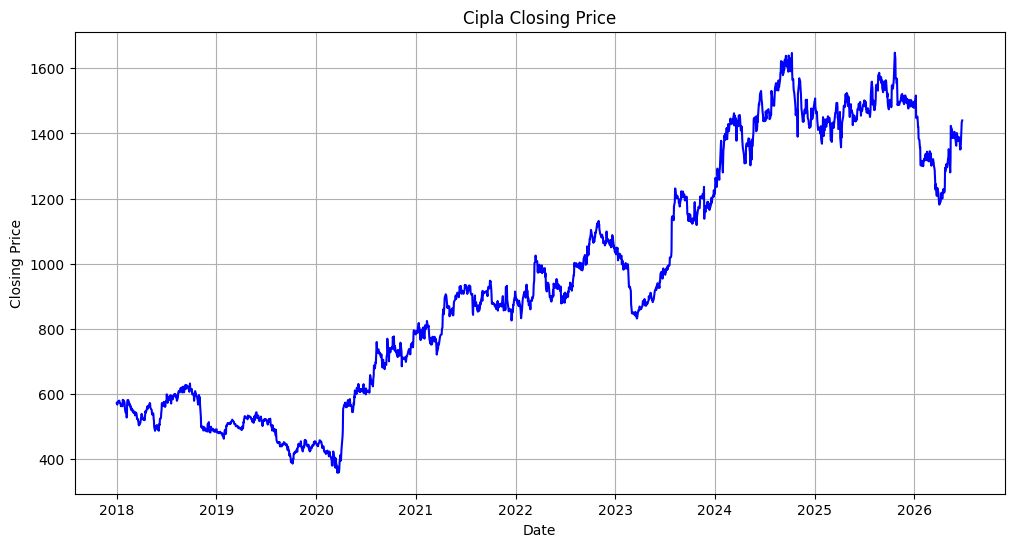

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    data.index,
    data["Close"],
    color="blue"
)

plt.title("Cipla Closing Price")

plt.xlabel("Date")

plt.ylabel("Closing Price")

plt.grid(True)

plt.show()

In [ ]:
data.to_csv("cipla_close.csv")

In [ ]:
data.head()

Price,Close
Ticker,CIPLA.NS
Date,
2018-01-01,571.370361
2018-01-02,567.913147
2018-01-03,566.978760
2018-01-04,576.275696
2018-01-05,574.780762


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2096 entries, 2018-01-01 to 2026-06-25
Data columns (total 1 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, CIPLA.NS)  2096 non-null   float64
dtypes: float64(1)
memory usage: 32.8 KB


In [ ]:
data.describe()

Price,Close
Ticker,CIPLA.NS
count,2096.000000
mean,955.134314
std,373.417769
min,357.556427
25%,588.327179
50%,907.617676
75%,1334.777771
max,1648.137939


In [ ]:
print(data.isnull().sum())

Price  Ticker  
Close  CIPLA.NS    0
dtype: int64


In [ ]:
dataset = data.values

print(dataset.shape)

(2096, 1)


In [ ]:
training_size = int(len(dataset) * 0.80)

train_data = dataset[:training_size]

test_data = dataset[training_size:]

print("Training Data :", train_data.shape)

print("Testing Data :", test_data.shape)

Training Data : (1676, 1)
Testing Data : (420, 1)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

train_scaled = scaler.fit_transform(train_data)

test_scaled = scaler.transform(test_data)

In [ ]:
time_step = 120

In [ ]:
def create_dataset(dataset, time_step):

    X = []

    y = []

    for i in range(time_step, len(dataset)):

        X.append(dataset[i-time_step:i, 0])

        y.append(dataset[i, 0])

    return np.array(X), np.array(y)

In [ ]:
X_train, y_train = create_dataset(
    train_scaled,
    time_step
)

X_test, y_test = create_dataset(
    test_scaled,
    time_step
)

print("X_train :", X_train.shape)

print("y_train :", y_train.shape)

print("X_test :", X_test.shape)

print("y_test :", y_test.shape)

X_train : (1556, 120)
y_train : (1556,)
X_test : (300, 120)
y_test : (300,)


In [ ]:
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

In [ ]:
print("X_train Shape :", X_train.shape)

print("X_test Shape :", X_test.shape)

print("y_train Shape :", y_train.shape)

print("y_test Shape :", y_test.shape)

X_train Shape : (1556, 120, 1)
X_test Shape : (300, 120, 1)
y_train Shape : (1556,)
y_test Shape : (300,)


In [ ]:
print("First Training Sequence:\n")
print(X_train[0])

print("\nTarget Value:\n")
print(y_train[0])

First Training Sequence:

[[0.16578225]
 [0.16310168]
 [0.16237719]
 [0.16958564]
 [0.16842653]
 [0.16835403]
 [0.1687525 ]
 [0.17175914]
 [0.16639799]
 [0.16621683]
 [0.16487666]
 [0.15846501]
 [0.1626308 ]
 [0.16009513]
 [0.15944301]
 [0.1582839 ]
 [0.17364274]
 [0.1707086 ]
 [0.17295455]
 [0.16831788]
 [0.16176141]
 [0.15176349]
 [0.14806876]
 [0.1437944 ]
 [0.14303362]
 [0.13155081]
 [0.13517314]
 [0.16661539]
 [0.17295455]
 [0.17313561]
 [0.16915102]
 [0.16168886]
 [0.16549244]
 [0.15774052]
 [0.15995018]
 [0.15545846]
 [0.14995249]
 [0.15429926]
 [0.15027842]
 [0.14767034]
 [0.14995249]
 [0.14419292]
 [0.14241789]
 [0.14593156]
 [0.14310612]
 [0.14151225]
 [0.13647715]
 [0.14343223]
 [0.14205562]
 [0.14143989]
 [0.13654961]
 [0.12803705]
 [0.12829061]
 [0.12332802]
 [0.12198771]
 [0.1145256 ]
 [0.11282309]
 [0.11528636]
 [0.11764092]
 [0.11793069]
 [0.14024443]
 [0.13593373]
 [0.13557161]
 [0.12872524]
 [0.12771103]
 [0.12611721]
 [0.1271315 ]
 [0.12955842]
 [0.12568253]
 [0.1252

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
# ==========================================
# Build Stacked LSTM Model
# ==========================================

model = Sequential()

# First LSTM Layer
model.add(
    LSTM(
        units=50,
        return_sequences=True,
        input_shape=(
            X_train.shape[1],
            1
        )
    )
)

# Dropout Layer
model.add(
    Dropout(0.2)
)

# Second LSTM Layer
model.add(
    LSTM(
        units=50,
        return_sequences=False
    )
)

# Dropout Layer
model.add(
    Dropout(0.2)
)

# Output Layer
model.add(
    Dense(1)
)

In [ ]:
optimizer = Adam(
    learning_rate=0.0005
)

model.compile(
    optimizer=optimizer,
    loss='mean_squared_error'
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 120, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 120, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.10,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step - loss: 0.0238 - val_loss: 0.0021
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 133ms/step - loss: 0.0031 - val_loss: 0.0010
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - loss: 0.0025 - val_loss: 9.4456e-04
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - loss: 0.0022 - val_loss: 0.0025
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - loss: 0.0022 - val_loss: 0.0015
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 133ms/step - loss: 0.0018 - val_loss: 0.0014
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - loss: 0.0019 - val_loss: 0.0025
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - loss: 0.0017 - val_loss: 9.0517e-04
Epoch 9/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 103ms/step - loss: 0.0016 - val_loss: 8.5695e-04
Epoch 10/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 136ms/step - loss: 0.0016 - val_loss: 0.0017
Epoch 11/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - loss: 0.0016 - val_loss: 0.0011
Epoch 12/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
print("Training Completed Successfully!")

Training Completed Successfully!


In [ ]:
print("Total Epochs Trained :", len(history.history['loss']))

Total Epochs Trained : 20


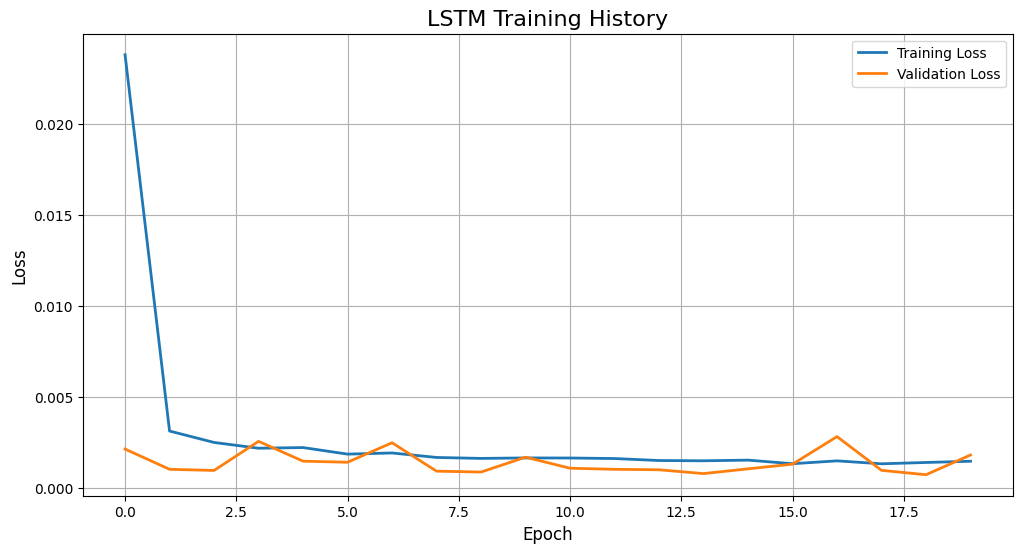

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    history.history['loss'],
    label='Training Loss',
    linewidth=2
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss',
    linewidth=2
)

plt.title("LSTM Training History", fontsize=16)

plt.xlabel("Epoch", fontsize=12)

plt.ylabel("Loss", fontsize=12)

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# ============================================
# Predict Test Data
# ============================================

predicted_price = model.predict(X_test)

print(predicted_price.shape)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step
(300, 1)


In [ ]:
# ============================================
# Convert Back to Original Scale
# ============================================

predicted_price = scaler.inverse_transform(
    predicted_price
)

actual_price = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

In [ ]:
comparison = pd.DataFrame({

    "Actual Price":actual_price.flatten(),

    "Predicted Price":predicted_price.flatten()

})

comparison.head()

,Actual Price,Predicted Price
0,1434.132080,1431.812378
1,1452.511475,1427.386963
2,1466.822754,1426.147339
3,1485.251221,1427.889648
4,1481.232300,1432.567139


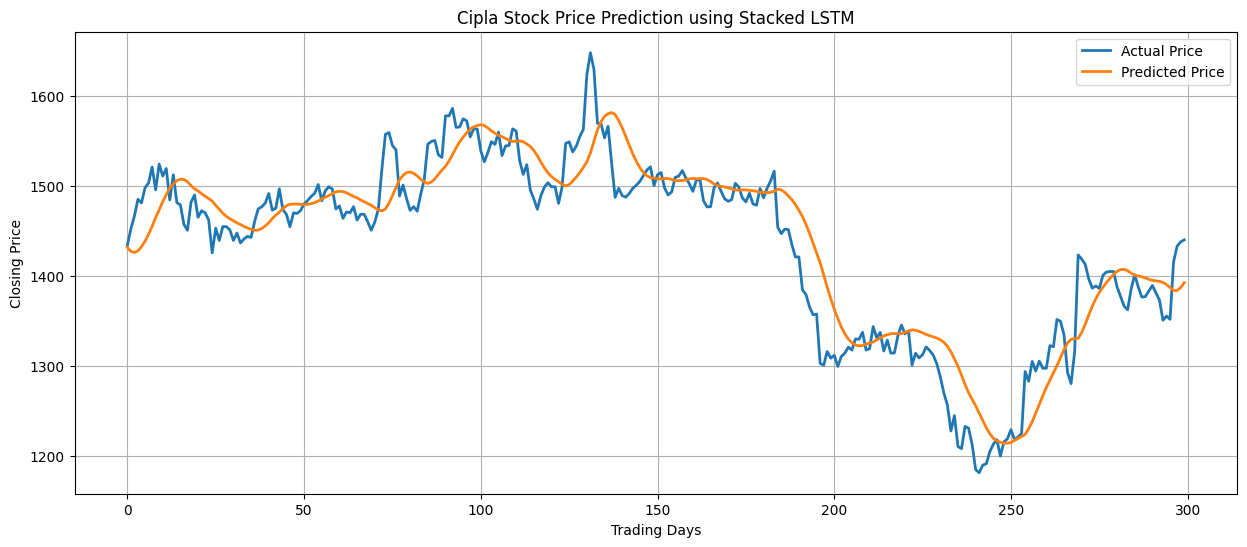

In [ ]:
# ============================================
# Actual vs Predicted
# ============================================

plt.figure(figsize=(15,6))

plt.plot(

    actual_price,

    label="Actual Price",

    linewidth=2

)

plt.plot(

    predicted_price,

    label="Predicted Price",

    linewidth=2

)

plt.title("Cipla Stock Price Prediction using Stacked LSTM")

plt.xlabel("Trading Days")

plt.ylabel("Closing Price")

plt.legend()

plt.grid(True)

plt.show()

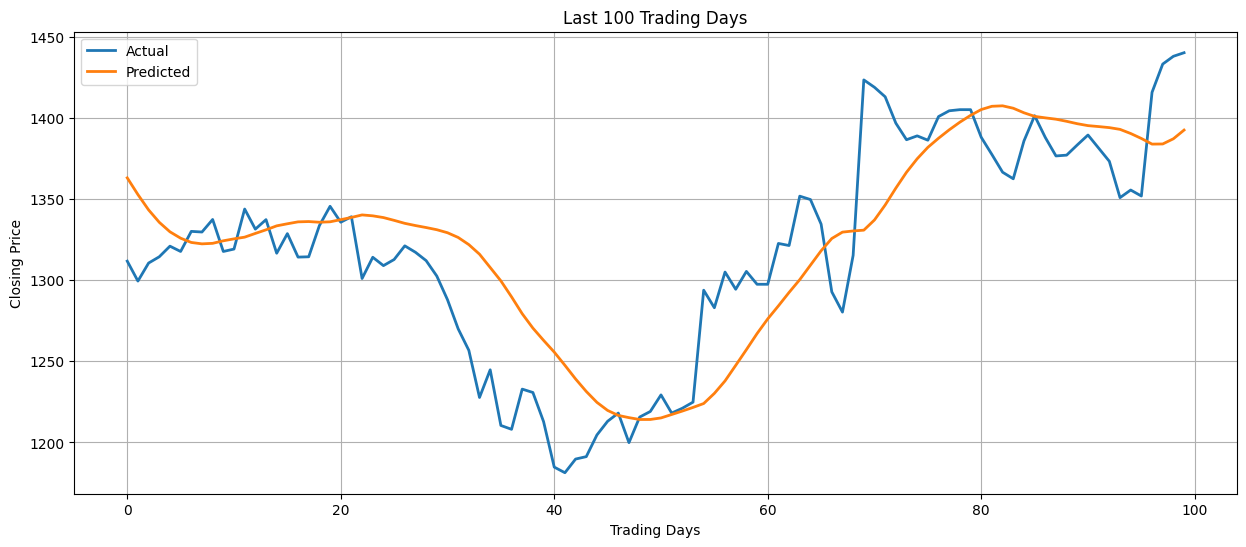

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(

    actual_price[-100:],

    label="Actual",

    linewidth=2

)

plt.plot(

    predicted_price[-100:],

    label="Predicted",

    linewidth=2

)

plt.title("Last 100 Trading Days")

plt.xlabel("Trading Days")

plt.ylabel("Closing Price")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
prediction_df = pd.DataFrame({

    "Actual Price":actual_price.flatten(),

    "Predicted Price":predicted_price.flatten()

})

prediction_df.to_csv(

    "Cipla_Test_Predictions.csv",

    index=False

)

print("Prediction file saved successfully.")

Prediction file saved successfully.


In [ ]:
prediction_df["Error"] = (

    prediction_df["Actual Price"]

    -

    prediction_df["Predicted Price"]

)

prediction_df.head()

,Actual Price,Predicted Price,Error
0,1434.132080,1431.812378,2.319702
1,1452.511475,1427.386963,25.124512
2,1466.822754,1426.147339,40.675415
3,1485.251221,1427.889648,57.361572
4,1481.232300,1432.567139,48.665161


In [ ]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)

import numpy as np

In [ ]:
# ==========================================
# Root Mean Squared Error
# ==========================================

rmse = np.sqrt(
    mean_squared_error(
        actual_price,
        predicted_price
    )
)

print("RMSE :", rmse)

RMSE : 36.94086108780967


In [ ]:
# ==========================================
# Mean Absolute Error
# ==========================================

mae = mean_absolute_error(
    actual_price,
    predicted_price
)

print("MAE :", mae)

MAE : 28.329625244140637


In [ ]:
# ==========================================
# Mean Absolute Percentage Error
# ==========================================

mape = mean_absolute_percentage_error(
    actual_price,
    predicted_price
)

print("MAPE :", mape * 100, "%")

MAPE : 2.0025455501431293 %


In [ ]:
# ==========================================
# R² Score
# ==========================================

r2 = r2_score(
    actual_price,
    predicted_price
)

print("R² Score :", r2)

R² Score : 0.8650494006350196


In [ ]:
print("="*40)

print("LSTM MODEL PERFORMANCE")

print("="*40)

print(f"RMSE      : {rmse:.4f}")

print(f"MAE       : {mae:.4f}")

print(f"MAPE      : {mape*100:.2f}%")

print(f"R² Score  : {r2:.4f}")

print("="*40)

LSTM MODEL PERFORMANCE
RMSE      : 36.9409
MAE       : 28.3296
MAPE      : 2.00%
R² Score  : 0.8650


In [ ]:
# ==========================================
# Forecast Next 7 Trading Days
# ==========================================

future_days = 7

In [ ]:
last_90_days = scaler.transform(
    dataset[-time_step:]
)

In [ ]:
print(last_90_days.shape)

(120, 1)


In [ ]:
future_predictions = []

In [ ]:
current_input = last_90_days.reshape(
    1,
    time_step,
    1
)

In [ ]:
for i in range(future_days):

    next_price = model.predict(
        current_input,
        verbose=0
    )

    future_predictions.append(
        next_price[0,0]
    )

    current_input = np.append(

        current_input[:,1:,:],

        next_price.reshape(
            1,
            1,
            1
        ),

        axis=1

    )

In [ ]:
future_predictions = np.array(
    future_predictions
).reshape(-1,1)

forecast_prices = scaler.inverse_transform(
    future_predictions
)

In [ ]:
future_dates = pd.bdate_range(

    start=data.index[-1] + pd.Timedelta(days=1),

    periods=future_days

)

In [ ]:
forecast_df = pd.DataFrame({

    "Date":future_dates,

    "Forecast Close Price":
    forecast_prices.flatten()

})

forecast_df

,Date,Forecast Close Price
0,2026-06-26,1399.123047
1,2026-06-29,1403.987549
2,2026-06-30,1407.826050
3,2026-07-01,1410.945068
4,2026-07-02,1413.563843
5,2026-07-03,1415.834106
6,2026-07-06,1417.861694


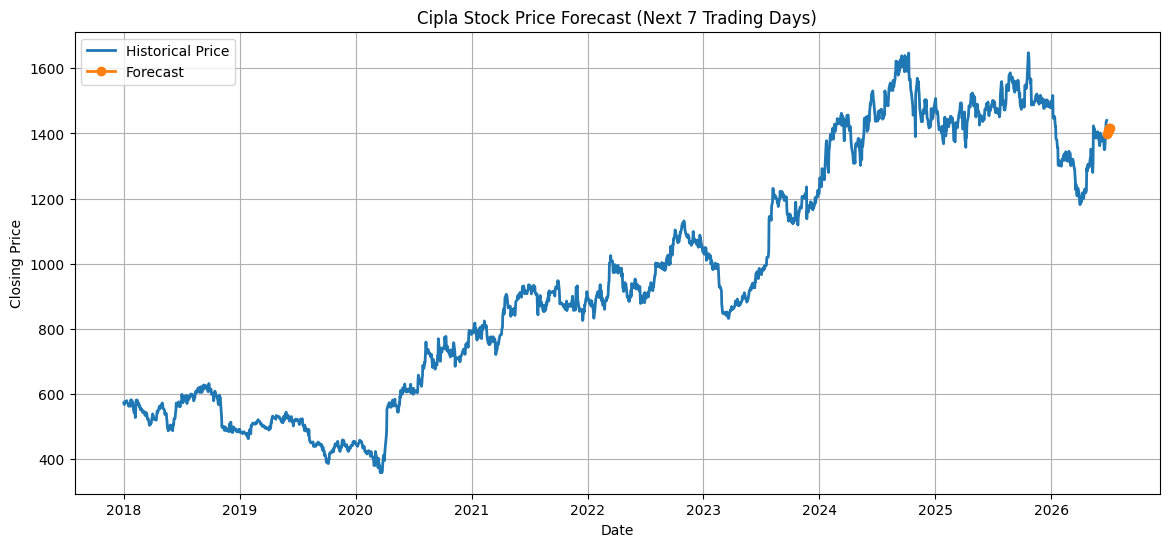

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(

    data.index,

    data["Close"],

    label="Historical Price",

    linewidth=2

)

plt.plot(

    forecast_df["Date"],

    forecast_df["Forecast Close Price"],

    marker='o',

    linewidth=2,

    label="Forecast"

)

plt.title("Cipla Stock Price Forecast (Next 7 Trading Days)")

plt.xlabel("Date")

plt.ylabel("Closing Price")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
final_forecast = forecast_df[
    "Forecast Close Price"
].iloc[-1]

print(
    "Forecast Price after",
    future_days,
    "Trading Days :",
    final_forecast
)

Forecast Price after 7 Trading Days : 1417.8617


DEEP AR

In [ ]:
!pip install gluonts
!pip install lightning
!pip install pytorch-lightning

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from gluonts.dataset.common import ListDataset

import warnings
warnings.filterwarnings("ignore")

In [ ]:
stock_price = df[['Close']].copy()

stock_price.head()

Price,Close
Ticker,CIPLA.NS
Date,
2018-01-01,571.370361
2018-01-02,567.913147
2018-01-03,566.978760
2018-01-04,576.275696
2018-01-05,574.780762


In [ ]:
stock_price["Log_Return"] = np.log(

    stock_price["Close"]

    /

    stock_price["Close"].shift(1)

)

In [ ]:
stock_price.head()

Price,Close,Log_Return
Ticker,CIPLA.NS,
Date,,
2018-01-01,571.370361,NaN
2018-01-02,567.913147,-0.006069
2018-01-03,566.978760,-0.001647
2018-01-04,576.275696,0.016264
2018-01-05,574.780762,-0.002598


In [ ]:
stock_price = stock_price.dropna()

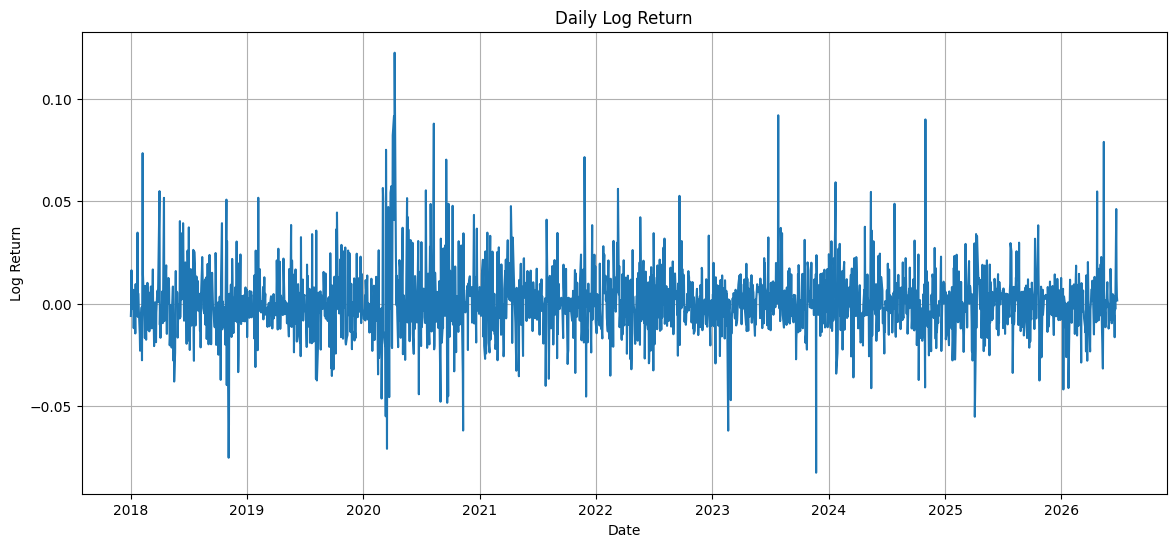

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(

    stock_price.index,

    stock_price["Log_Return"]

)

plt.title("Daily Log Return")

plt.xlabel("Date")

plt.ylabel("Log Return")

plt.grid(True)

plt.show()

In [ ]:
stock_price["Log_Return"].describe()

,Log_Return
count,2095.000000
mean,0.000441
std,0.016350
min,-0.082638
25%,-0.008378
50%,-0.000312
75%,0.007833
max,0.122550


In [ ]:
train_size = int(

    len(stock_price)

    *

    0.80

)

train = stock_price.iloc[:train_size]

test = stock_price.iloc[train_size:]

In [ ]:
print("Training Size :", len(train))

print("Testing Size :", len(test))

Training Size : 1676
Testing Size : 419


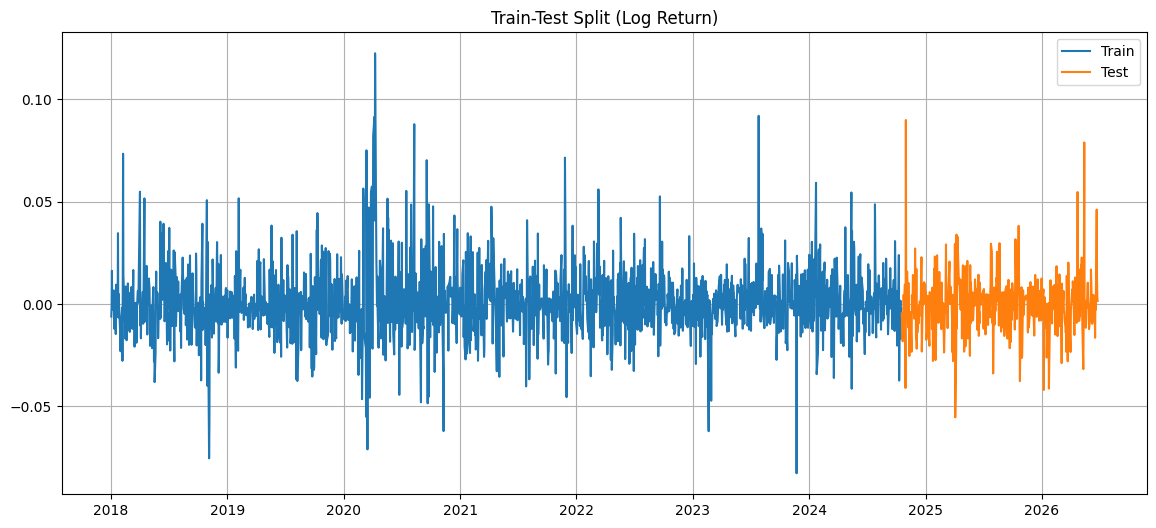

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(

    train.index,

    train["Log_Return"],

    label="Train"

)

plt.plot(

    test.index,

    test["Log_Return"],

    label="Test"

)

plt.legend()

plt.title("Train-Test Split (Log Return)")

plt.grid(True)

plt.show()

In [ ]:
from gluonts.dataset.common import ListDataset
from gluonts.torch.model.deepar import DeepAREstimator
from gluonts.evaluation.backtest import make_evaluation_predictions

from lightning.pytorch import Trainer

In [ ]:
# ==========================================
# DeepAR Parameters
# ==========================================

prediction_length = 7

context_length = 120

freq = "B"

In [ ]:
train_dataset = ListDataset(
    [
        {
            "start": train.index[0],
            "target": train["Log_Return"].values
        }
    ],
    freq=freq
)

In [ ]:
test_dataset = ListDataset(
    [
        {
            "start": stock_price.index[0],
            "target": stock_price["Log_Return"].values
        }
    ],
    freq=freq
)

In [ ]:
print(train_dataset)

[{'start': Period('2018-01-02', 'B'), 'target': array([-0.00606912, -0.00164665,  0.01626434, ..., -0.01684475,
       -0.00609462, -0.00224292], dtype=float32)}]


In [ ]:
for item in train_dataset:

    print(item)

    break

{'start': Period('2018-01-02', 'B'), 'target': array([-0.00606912, -0.00164665,  0.01626434, ..., -0.01684475,
       -0.00609462, -0.00224292], dtype=float32)}


In [ ]:
print("Training Samples :", len(train))

print("Testing Samples :", len(test))

print("Context Length :", context_length)

print("Prediction Length :", prediction_length)

Training Samples : 1676
Testing Samples : 419
Context Length : 120
Prediction Length : 7


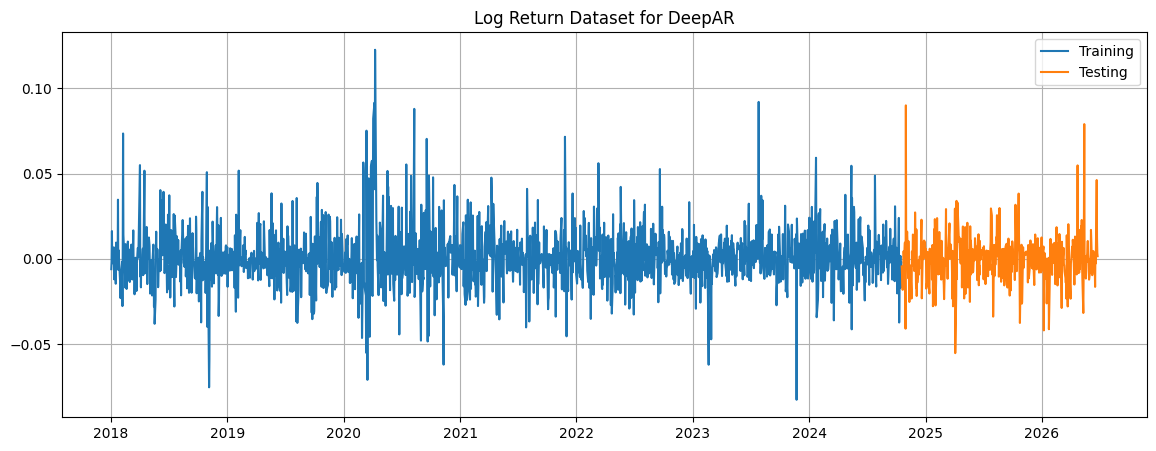

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(
    train.index,
    train["Log_Return"],
    label="Training"
)

plt.plot(
    test.index,
    test["Log_Return"],
    label="Testing"
)

plt.title("Log Return Dataset for DeepAR")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
from gluonts.torch.model.deepar import DeepAREstimator
from gluonts.torch.distributions import StudentTOutput
from gluonts.evaluation.backtest import make_evaluation_predictions


In [ ]:
# ==========================================
# Build DeepAR Model
# ==========================================

estimator = DeepAREstimator(

    prediction_length=prediction_length,

    context_length=context_length,

    freq=freq,

    num_layers=2,

    hidden_size=50,

    dropout_rate=0.2,

    lr=0.001,

    batch_size=32,

    num_batches_per_epoch=50,

    distr_output=StudentTOutput()

)

In [ ]:
!pip uninstall -y torch torchvision torchaudio lightning pytorch-lightning gluonts

Found existing installation: torch 2.5.1
Uninstalling torch-2.5.1:
  Successfully uninstalled torch-2.5.1
Found existing installation: lightning 2.4.0
Uninstalling lightning-2.4.0:
  Successfully uninstalled lightning-2.4.0
Found existing installation: pytorch-lightning 2.4.0
Uninstalling pytorch-lightning-2.4.0:
  Successfully uninstalled pytorch-lightning-2.4.0
Found existing installation: gluonts 0.15.1
Uninstalling gluonts-0.15.1:
  Successfully uninstalled gluonts-0.15.1


In [ ]:
!pip install torch==2.5.1
!pip install lightning==2.4.0
!pip install pytorch-lightning==2.4.0
!pip install gluonts==0.15.1

  Using cached torch-2.5.1-cp312-cp312-manylinux1_x86_64.whl.metadata (28 kB)
Using cached torch-2.5.1-cp312-cp312-manylinux1_x86_64.whl (906.4 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fastai 2.8.7 requires torchvision>=0.11, which is not installed.
timm 1.0.27 requires torchvision, which is not installed.


  Using cached lightning-2.4.0-py3-none-any.whl.metadata (38 kB)
  Using cached pytorch_lightning-2.6.5-py3-none-any.whl.metadata (21 kB)
Using cached lightning-2.4.0-py3-none-any.whl (810 kB)
Using cached pytorch_lightning-2.6.5-py3-none-any.whl (852 kB)


  Using cached pytorch_lightning-2.4.0-py3-none-any.whl.metadata (21 kB)
Using cached pytorch_lightning-2.4.0-py3-none-any.whl (815 kB)
  Attempting uninstall: pytorch-lightning
    Found existing installation: pytorch-lightning 2.6.5
    Uninstalling pytorch-lightning-2.6.5:
      Successfully uninstalled pytorch-lightning-2.6.5


  Using cached gluonts-0.15.1-py3-none-any.whl.metadata (9.9 kB)
Using cached gluonts-0.15.1-py3-none-any.whl (1.5 MB)


In [ ]:
import torch
import gluonts
import lightning
import pytorch_lightning

print(torch.__version__)
print(gluonts.__version__)
print(lightning.__version__)
print(pytorch_lightning.__version__)

2.5.1+cu124
0.15.1
2.4.0
2.4.0


In [ ]:
# ==========================================
# Train DeepAR Model
# ==========================================

predictor = estimator.train(

    training_data=train_dataset

)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: 
  | Name  | Type        | Params | Mode  | In sizes                                                     | Out sizes  
---------------------------------------------------------------------------------------------------------------------------
0 | model | DeepARModel | 38.2 K | train | [[1, 1], [1, 1], [1, 899, 4], [1, 899], [1, 899], [1, 7, 4]] | [1, 100, 7]
---------------------------------------------------------------------------------------------------------------------------
38.2 K    Trainable params
0         Non-trainable params
38.2 K    Total params
0.153     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name  | Type        | Pa

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:Epoch 0, global step 50: 'train_loss' reached -2.69348 (best -2.69348), saving model to '/content/lightning_logs/version_3/checkpoints/epoch=0-step=50.ckpt' as top 1
INFO:pytorch_lightning.utilities.rank_zero:Epoch 1, global step 100: 'train_loss' reached -2.78838 (best -2.78838), saving model to '/content/lightning_logs/version_3/checkpoints/epoch=1-step=100.ckpt' as top 1
INFO:pytorch_lightning.utilities.rank_zero:Epoch 2, global step 150: 'train_loss' reached -2.99005 (best -2.99005), saving model to '/content/lightning_logs/version_3/checkpoints/epoch=2-step=150.ckpt' as top 1
INFO:pytorch_lightning.utilities.rank_zero:Epoch 3, global step 200: 'train_loss' reached -3.14721 (best -3.14721), saving model to '/content/lightning_logs/version_3/checkpoints/epoch=3-step=200.ckpt' as top 1
INFO:pytorch_lightning.utilities.rank_zero:Epoch 4, global step 250: 'train_loss' reached -3.32209 (best -3.32209), saving model to '/content/lightning_logs/v

In [ ]:
# ==========================================
# Generate Forecast
# ==========================================

forecast_it, ts_it = make_evaluation_predictions(
    dataset=test_dataset,
    predictor=predictor,
    num_samples=100
)

In [ ]:
forecasts = list(forecast_it)
targets = list(ts_it)

In [ ]:
forecast = forecasts[0]

In [ ]:
print(forecast)

gluonts.model.forecast.SampleForecast(info=None, item_id=None, samples=array([[ 4.65959962e-03, -1.15133962e-02, -2.34774849e-03,
        -4.76460578e-03,  1.93705428e-02, -4.89599863e-03,
         1.05778202e-02],
       [ 3.62478592e-03, -1.21435309e-02, -9.98720061e-04,
        -5.78380935e-03,  1.89347696e-02, -2.90319766e-03,
         8.31320509e-03],
       [ 4.49211197e-03, -1.43014733e-02,  2.89052189e-03,
        -7.15357251e-03,  1.70786772e-02, -2.82789697e-03,
         5.64213796e-03],
       [ 4.34113666e-03, -1.12021305e-02, -2.53679533e-03,
        -5.73906023e-03,  1.91509146e-02, -3.06620589e-03,
         9.24435444e-03],
       [ 5.43953897e-03, -1.25209587e-02, -1.52227550e-03,
        -6.35728007e-03,  1.83952395e-02, -4.62640729e-03,
         1.12425471e-02],
       [ 5.14761964e-03, -1.32006640e-02, -1.71139278e-03,
        -5.65444306e-03,  1.74667258e-02, -1.64272147e-03,
         5.76387392e-03],
       [ 3.93959600e-03, -1.10366670e-02, -2.44726054e-03,
      

In [ ]:
predicted_log_returns = forecast.mean

print(predicted_log_returns)

[ 0.00462551 -0.01255972 -0.00064125 -0.00615408  0.01818357 -0.00277249
  0.00717305]


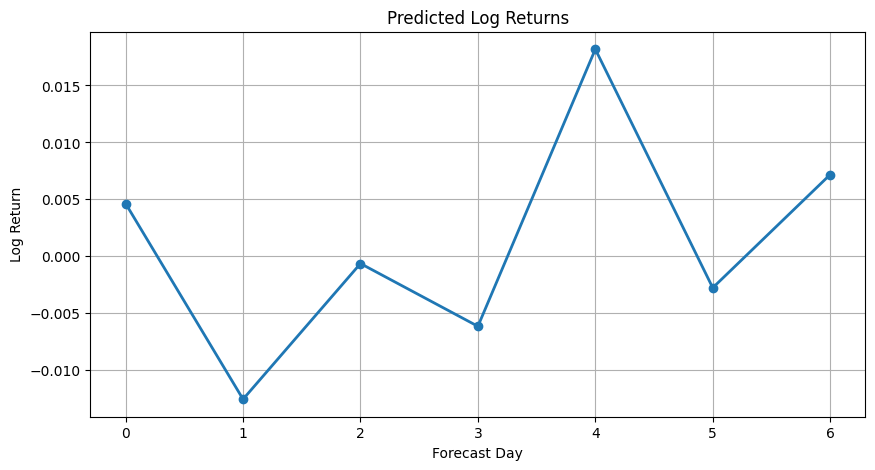

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    predicted_log_returns,
    marker='o',
    linewidth=2
)

plt.title("Predicted Log Returns")

plt.xlabel("Forecast Day")

plt.ylabel("Log Return")

plt.grid(True)

plt.show()

In [ ]:
future_dates = pd.bdate_range(

    start=stock_price.index[-1] + pd.Timedelta(days=1),

    periods=7

)

In [ ]:
forecast_return_df = pd.DataFrame({

    "Date":future_dates,

    "Predicted_Log_Return":predicted_log_returns

})

forecast_return_df

,Date,Predicted_Log_Return
0,2026-06-26,0.004626
1,2026-06-29,-0.012560
2,2026-06-30,-0.000641
3,2026-07-01,-0.006154
4,2026-07-02,0.018184
5,2026-07-03,-0.002772
6,2026-07-06,0.007173


In [ ]:
# ==========================================
# Last Available Closing Price
# ==========================================

last_close = stock_price["Close"].iloc[-1]

print("Last Closing Price :", last_close)

Last Closing Price : Ticker
CIPLA.NS    1440.099976
Name: 2026-06-25 00:00:00, dtype: float64


In [ ]:
future_close_prices = []

In [ ]:
current_price = last_close

for r in predicted_log_returns:

    current_price = current_price * np.exp(r)

    future_close_prices.append(current_price)

In [ ]:
future_close_prices

[Ticker
 CIPLA.NS    1446.776522
 Name: 2026-06-25 00:00:00, dtype: float64,
 Ticker
 CIPLA.NS    1428.719169
 Name: 2026-06-25 00:00:00, dtype: float64,
 Ticker
 CIPLA.NS    1427.803376
 Name: 2026-06-25 00:00:00, dtype: float64,
 Ticker
 CIPLA.NS    1419.043566
 Name: 2026-06-25 00:00:00, dtype: float64,
 Ticker
 CIPLA.NS    1445.082854
 Name: 2026-06-25 00:00:00, dtype: float64,
 Ticker
 CIPLA.NS    1441.081946
 Name: 2026-06-25 00:00:00, dtype: float64,
 Ticker
 CIPLA.NS    1451.456193
 Name: 2026-06-25 00:00:00, dtype: float64]

In [ ]:
forecast_price_df = pd.DataFrame({

    "Date":future_dates,

    "Predicted Close Price":future_close_prices

})

forecast_price_df

,Date,Predicted Close Price
0,2026-06-26,Ticker CIPLA.NS 1446.776522 Name: 2026-06-2...
1,2026-06-29,Ticker CIPLA.NS 1428.719169 Name: 2026-06-2...
2,2026-06-30,Ticker CIPLA.NS 1427.803376 Name: 2026-06-2...
3,2026-07-01,Ticker CIPLA.NS 1419.043566 Name: 2026-06-2...
4,2026-07-02,Ticker CIPLA.NS 1445.082854 Name: 2026-06-2...
5,2026-07-03,Ticker CIPLA.NS 1441.081946 Name: 2026-06-2...
6,2026-07-06,Ticker CIPLA.NS 1451.456193 Name: 2026-06-2...


In [ ]:
forecast_price_df.to_csv(

    "DeepAR_Close_Price_Forecast.csv",

    index=False

)

print("Forecast Saved Successfully!")

Forecast Saved Successfully!


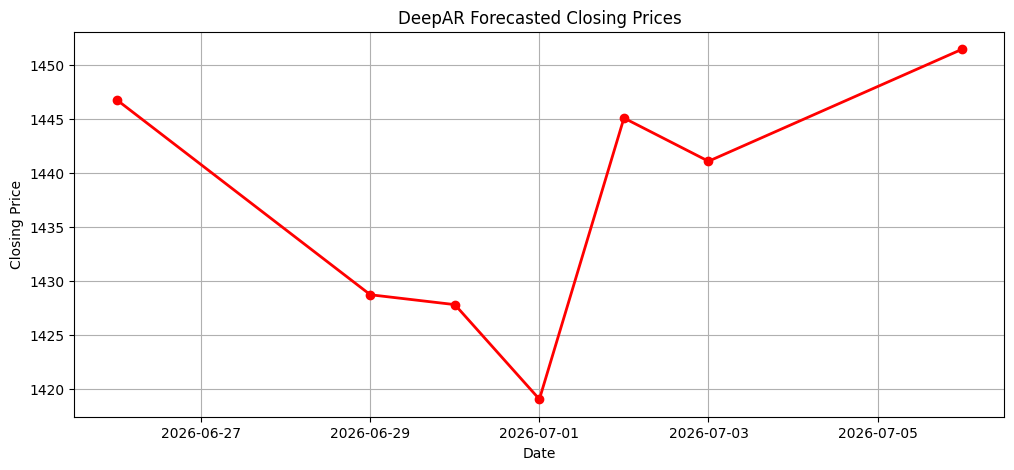

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(

    forecast_price_df["Date"],

    forecast_price_df["Predicted Close Price"],

    marker='o',

    linewidth=2,

    color="red"

)

plt.title("DeepAR Forecasted Closing Prices")

plt.xlabel("Date")

plt.ylabel("Closing Price")

plt.grid(True)

plt.show()

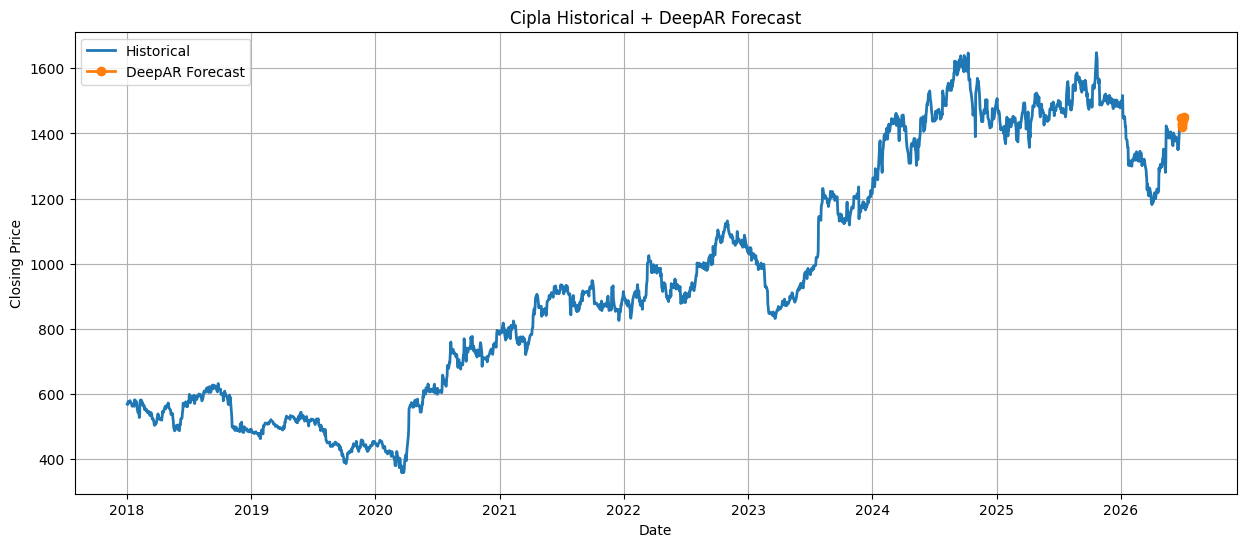

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(

    stock_price.index,

    stock_price["Close"],

    label="Historical",

    linewidth=2

)

plt.plot(

    forecast_price_df["Date"],

    forecast_price_df["Predicted Close Price"],

    marker='o',

    linewidth=2,

    label="DeepAR Forecast"

)

plt.title("Cipla Historical + DeepAR Forecast")

plt.xlabel("Date")

plt.ylabel("Closing Price")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
print(forecast_price_df)

        Date                              Predicted Close Price
0 2026-06-26  Ticker
CIPLA.NS    1446.776522
Name: 2026-06-2...
1 2026-06-29  Ticker
CIPLA.NS    1428.719169
Name: 2026-06-2...
2 2026-06-30  Ticker
CIPLA.NS    1427.803376
Name: 2026-06-2...
3 2026-07-01  Ticker
CIPLA.NS    1419.043566
Name: 2026-06-2...
4 2026-07-02  Ticker
CIPLA.NS    1445.082854
Name: 2026-06-2...
5 2026-07-03  Ticker
CIPLA.NS    1441.081946
Name: 2026-06-2...
6 2026-07-06  Ticker
CIPLA.NS    1451.456193
Name: 2026-06-2...


In [ ]:
from gluonts.evaluation import Evaluator
from gluonts.evaluation.backtest import make_evaluation_predictions

forecast_it, ts_it = make_evaluation_predictions(

    dataset=test_dataset,

    predictor=predictor,

    num_samples=100

)

forecasts = list(forecast_it)

targets = list(ts_it)

In [ ]:
evaluator = Evaluator()

agg_metrics, item_metrics = evaluator(

    targets,

    forecasts

)

Running evaluation: 1it [00:00, 12.21it/s]


In [ ]:
print(agg_metrics)

{'MSE': 0.0005068683531135321, 'abs_error': 0.10899192839860916, 'abs_target_sum': 0.08592882752418518, 'abs_target_mean': 0.012275546789169312, 'seasonal_error': 0.016697878569750847, 'MASE': 0.932470278812665, 'MAPE': 1.9835737773350306, 'sMAPE': 1.567349978855678, 'MSIS': 32.588525531070964, 'num_masked_target_values': 0.0, 'QuantileLoss[0.1]': 0.066665323311463, 'Coverage[0.1]': 0.5714285714285714, 'QuantileLoss[0.2]': 0.08001705277711155, 'Coverage[0.2]': 0.5714285714285714, 'QuantileLoss[0.3]': 0.0911633474752307, 'Coverage[0.3]': 0.5714285714285714, 'QuantileLoss[0.4]': 0.1003686873242259, 'Coverage[0.4]': 0.5714285714285714, 'QuantileLoss[0.5]': 0.1089919249061495, 'Coverage[0.5]': 0.5714285714285714, 'QuantileLoss[0.6]': 0.11737113799899816, 'Coverage[0.6]': 0.5714285714285714, 'QuantileLoss[0.7]': 0.12459863745607436, 'Coverage[0.7]': 0.5714285714285714, 'QuantileLoss[0.8]': 0.131424789596349, 'Coverage[0.8]': 0.5714285714285714, 'QuantileLoss[0.9]': 0.13607438378967346, 'Cov

In [ ]:
drmse = agg_metrics["RMSE"]

dmape = agg_metrics["MAPE"]

dsmape = agg_metrics["sMAPE"]

print("RMSE :", rmse)

print("MAPE :", mape)

print("sMAPE :", smape)

RMSE : 36.94086108780967
MAPE : 0.020025455501431293
sMAPE : 1.567349978855678


In [ ]:
from sklearn.metrics import mean_absolute_error

actual = targets[0][-prediction_length:]

predicted = forecasts[0].mean

dmae = mean_absolute_error(

    actual,

    predicted

)

print("MAE :", mae)

MAE : 28.329625244140637


In [ ]:
from sklearn.metrics import r2_score

dr2 = r2_score(

    actual,

    predicted

)

print("R² :", r2)

R² : 0.8650494006350196


In [ ]:
performance = pd.DataFrame({

    "Metric":[

        "RMSE",

        "MAE",

        "MAPE",

        "R²"

    ],

    "DeepAR":[

        drmse,

        dmae,

        dmape,

        dr2

    ]

})

performance

,Metric,DeepAR
0,RMSE,0.022514
1,MAE,0.015598
2,MAPE,1.983574
3,R²,-0.568033


In [ ]:
comparison = pd.DataFrame({

    "Metric":[

        "RMSE",

        "MAE",

        "MAPE",

        "R²"

    ],

    "LSTM":[

        rmse,

        mae,

        mape,

        r2

    ],

    "DeepAR":[

        drmse,

        dmae,

        dmape,

        dr2

    ]

})

comparison

,Metric,LSTM,DeepAR
0,RMSE,36.940861,0.022514
1,MAE,28.329625,0.015598
2,MAPE,0.020025,1.983574
3,R²,0.865049,-0.568033


In [ ]:
import numpy as np

# Last actual closing price before test starts
previous_price = stock_price["Close"].iloc[train_size - 1]

deepar_close_predictions = []

for r in predicted:
    previous_price = previous_price * np.exp(r)
    deepar_close_predictions.append(previous_price)

deepar_close_predictions = np.array(deepar_close_predictions)

In [ ]:
actual_close = stock_price["Close"].iloc[
    train_size:train_size + len(deepar_close_predictions)
].values

In [ ]:
# ==========================================
# LSTM vs DeepAR Forecast Comparison
# ==========================================

comparison_df = pd.DataFrame({
    "Date": forecast_df["Date"],
    "LSTM Closing Price": forecast_df["Forecast Close Price"].round(2),
    "DeepAR Closing Price": forecast_price_df["Predicted Close Price"].round(2)
})

comparison_df

,Date,LSTM Closing Price,DeepAR Closing Price
0,2026-06-26,1399.119995,Ticker CIPLA.NS 1446.776522 Name: 2026-06-2...
1,2026-06-29,1403.989990,Ticker CIPLA.NS 1428.719169 Name: 2026-06-2...
2,2026-06-30,1407.829956,Ticker CIPLA.NS 1427.803376 Name: 2026-06-2...
3,2026-07-01,1410.939941,Ticker CIPLA.NS 1419.043566 Name: 2026-06-2...
4,2026-07-02,1413.560059,Ticker CIPLA.NS 1445.082854 Name: 2026-06-2...
5,2026-07-03,1415.829956,Ticker CIPLA.NS 1441.081946 Name: 2026-06-2...
6,2026-07-06,1417.859985,Ticker CIPLA.NS 1451.456193 Name: 2026-06-2...
